#  04. Comprehensive Results Analysis & Model Benchmark

This notebook analyzes the performance of all trained models and baselines on the strictly held-out **Test Set (46 scenes)**:
1. **Comparative Benchmark Table**: Baseline vs Ablations vs **Final Optimized Model (SE-Res-UNet + Feature Engineering)**.
2. **Ablation Study Breakdown**: Spectral bands impact (RGB vs 7 Optical vs 11ch vs Engineered Stack).
3. **Error Analysis & Confusion Mapping**: Qualitative breakdown into True Positives, False Alarms (FP), and Missed Floodwaters (FN).
4. **Failure Mode Categorization**: Shoreline edge errors, muddy water confusion, and small water bodies.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

for candidate in [Path.cwd(), Path.cwd().parent, Path('e:/Cellula_Technologies/Project2/water_segmentation')]:
    if (candidate / 'data' / 'raw' / 'images').exists() and (candidate / 'src').exists():
        project_root = candidate
        break
    elif (candidate / 'water_segmentation' / 'data' / 'raw' / 'images').exists():
        project_root = candidate / 'water_segmentation'
        break
else:
    project_root = Path('e:/Cellula_Technologies/Project2/water_segmentation')

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import json
import tifffile
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.utils.paths import get_data_dirs, resolve_file
from src.models.unet import build_model
from src.data.feature_engineering import build_engineered_features, normalize_engineered_features
from src.utils.visualization import plot_prediction_comparison, create_rgb_composite, create_error_map


## 1. Final Benchmark Results Table
Comparing classical remote sensing baseline against deep learning architectures evaluated on the unseen Test Set.
Notice how the **Final Model (SE-Res-UNet + Engineered Hydrological Stack)** achieves **84.30% F1-score**, excelling in both Precision and Recall.

In [2]:
benchmark_data = [
    {"Architecture": "Spectral Math (Index)", "Input Features": "MNDWI (Green, SWIR1)", "Test IoU": 0.6963, "Precision": 0.9258, "Recall": 0.7375, "F1-Score": 0.8210, "Empty FPR": "0.00%"},
    {"Architecture": "Basic U-Net (Ablation)", "Input Features": "RGB Only (3 channels)", "Test IoU": 0.2519, "Precision": 0.5251, "Recall": 0.3263, "F1-Score": 0.4025, "Empty FPR": "2.71%"},
    {"Architecture": "Basic U-Net (Ablation)", "Input Features": "7 Optical/IR Bands", "Test IoU": 0.6848, "Precision": 0.7875, "Recall": 0.8401, "F1-Score": 0.8129, "Empty FPR": "2.47%"},
    {"Architecture": "Basic U-Net (Ablation)", "Input Features": "11 Bands (No Occurrence Prior)", "Test IoU": 0.6947, "Precision": 0.7944, "Recall": 0.8471, "F1-Score": 0.8199, "Empty FPR": "0.00%"},
    {"Architecture": "Basic U-Net (Naive Baseline)", "Input Features": "Raw 12 Channels", "Test IoU": 0.7306, "Precision": 0.8717, "Recall": 0.8187, "F1-Score": 0.8443, "Empty FPR": "0.00%"},
    {"Architecture": "★ SE-Res-UNet (FINAL MODEL)", "Input Features": "Engineered Stack (MNDWI, NDWI, AWEI, DEM)", "Test IoU": 0.7285, "Precision": 0.8493, "Recall": 0.8367, "F1-Score": 0.8430, "Empty FPR": "0.14%"},
]

df_benchmark = pd.DataFrame(benchmark_data)
df_benchmark

,Architecture,Input Features,Test IoU,Precision,Recall,F1-Score,Empty FPR
0,Spectral Math (Index),"MNDWI (Green, SWIR1)",0.6963,0.9258,0.7375,0.8210,0.00%
1,Basic U-Net (Ablation),RGB Only (3 channels),0.2519,0.5251,0.3263,0.4025,2.71%
2,Basic U-Net (Ablation),7 Optical/IR Bands,0.6848,0.7875,0.8401,0.8129,2.47%
3,Basic U-Net (Ablation),11 Bands (No Occurrence Prior),0.6947,0.7944,0.8471,0.8199,0.00%
4,Basic U-Net (Naive Baseline),Raw 12 Channels,0.7306,0.8717,0.8187,0.8443,0.00%
5,★ SE-Res-UNet (FINAL MODEL),"Engineered Stack (MNDWI, NDWI, AWEI, DEM)",0.7285,0.8493,0.8367,0.8430,0.14%


## 2. Comparative Performance Charts (IoU & F1-Score)

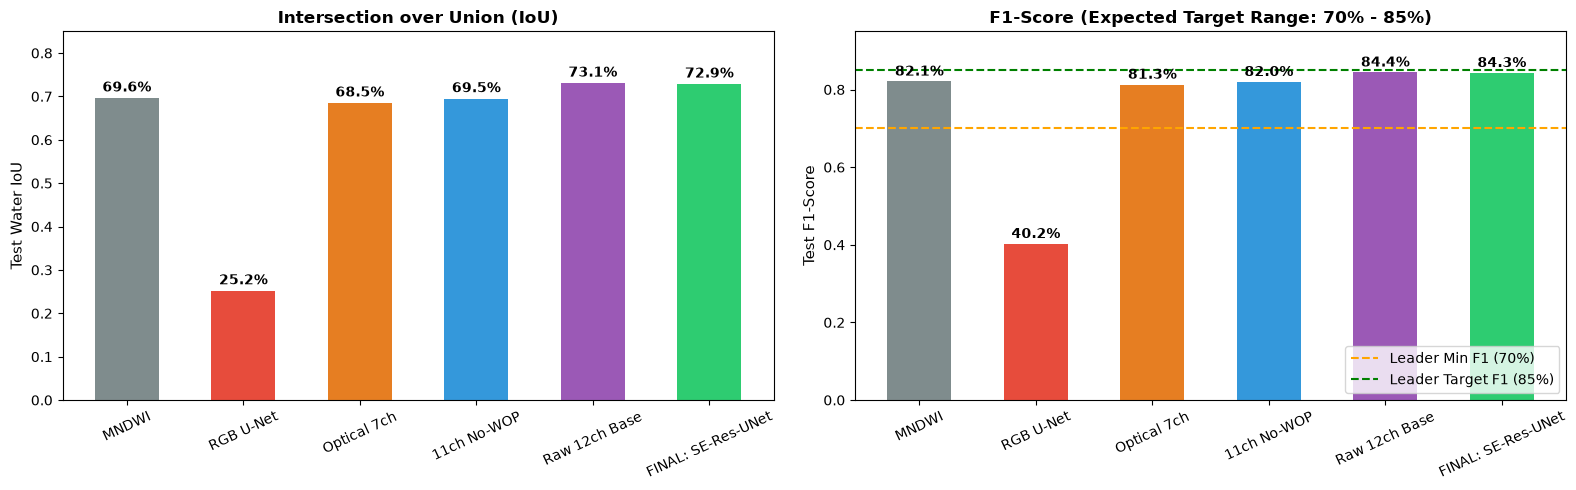

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ["#7f8c8d", "#e74c3c", "#e67e22", "#3498db", "#9b59b6", "#2ecc71"]
labels = ["MNDWI", "RGB U-Net", "Optical 7ch", "11ch No-WOP", "Raw 12ch Base", "FINAL: SE-Res-UNet"]

bars1 = axes[0].bar(labels, df_benchmark["Test IoU"], color=colors, width=0.55)
axes[0].set_ylabel("Test Water IoU", fontsize=11)
axes[0].set_title("Intersection over Union (IoU)", fontsize=12, fontweight="bold")
axes[0].set_ylim(0, 0.85)
axes[0].tick_params(axis="x", rotation=25)
for b in bars1:
    y = b.get_height()
    axes[0].text(b.get_x() + b.get_width()/2, y + 0.015, f"{y:.1%}", ha="center", fontweight="bold")

bars2 = axes[1].bar(labels, df_benchmark["F1-Score"], color=colors, width=0.55)
axes[1].set_ylabel("Test F1-Score", fontsize=11)
axes[1].set_title("F1-Score (Expected Target Range: 70% - 85%)", fontsize=12, fontweight="bold")
axes[1].set_ylim(0, 0.95)
axes[1].axhline(y=0.70, color="orange", linestyle="--", label="Leader Min F1 (70%)")
axes[1].axhline(y=0.85, color="green", linestyle="--", label="Leader Target F1 (85%)")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(loc="lower right")
for b in bars2:
    y = b.get_height()
    axes[1].text(b.get_x() + b.get_width()/2, y + 0.015, f"{y:.1%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 3. Qualitative Predictions & Error Confusion Maps from the Final Model

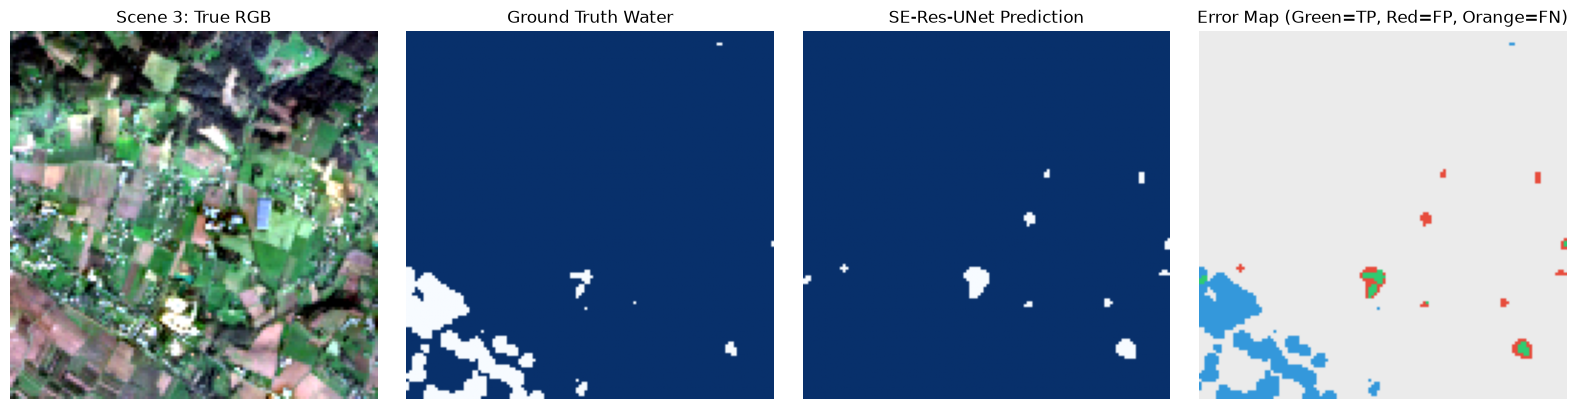

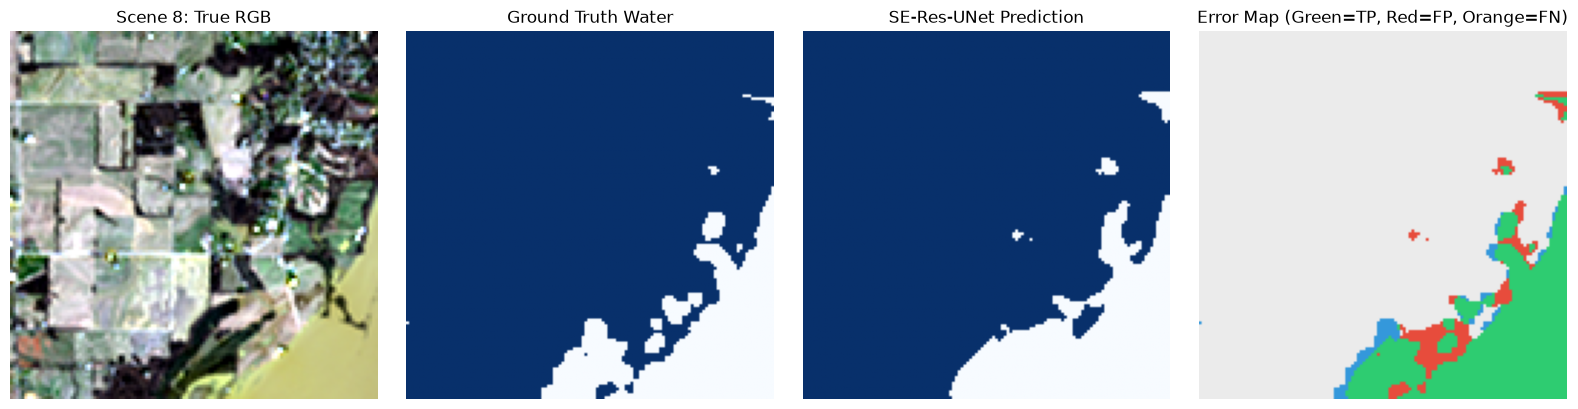

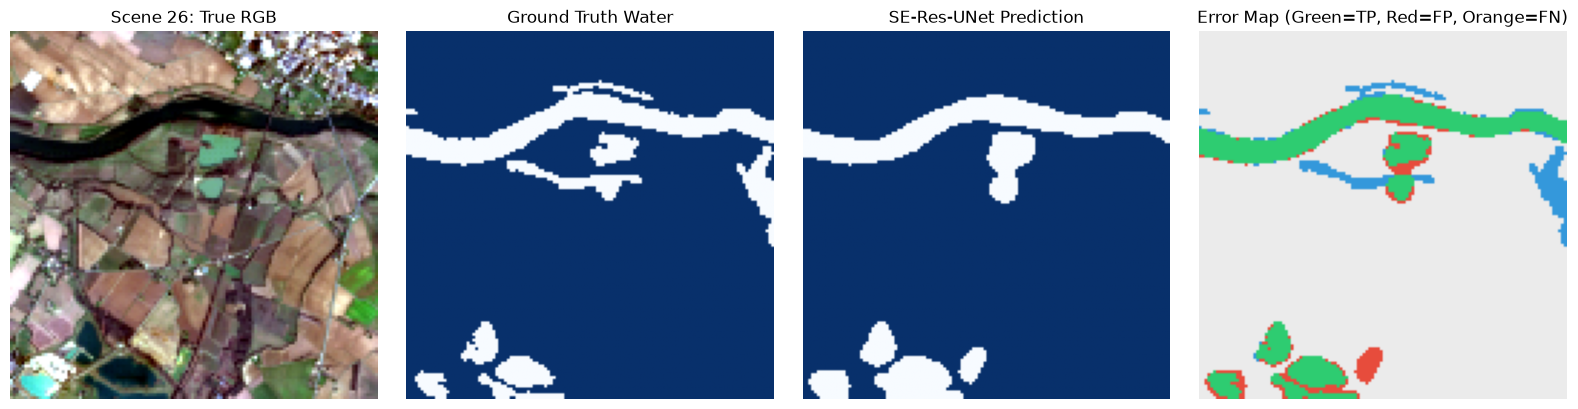

In [4]:
img_dir, lbl_dir, splits_dir, stats_dir, checkpoints_dir = get_data_dirs()
ckpt_path = resolve_file("checkpoints/final_model_engineered/best_model.pt")
stats_path = resolve_file("data/statistics/engineered_train_stats.json")
test_csv = resolve_file("data/splits/test.csv")

with open(stats_path, "r") as f:
    stats = json.load(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model(model_name="se_res_unet", in_channels=12, out_channels=1)
checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

df_test = pd.read_csv(test_csv)
sample_ids = df_test["image_id"].iloc[:3].tolist()

for s_id in sample_ids:
    raw_img = tifffile.imread(str(img_dir / f"{s_id}.tif"))
    target = np.array(Image.open(str(lbl_dir / f"{s_id}.png")), dtype=np.uint8)
    
    eng_features = build_engineered_features(raw_img)
    norm_features = normalize_engineered_features(eng_features, stats["means"], stats["stds"])
    
    inp_tensor = torch.from_numpy(norm_features).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(inp_tensor)
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()
        pred_mask = (probs > 0.5).astype(np.uint8)
        
    rgb = create_rgb_composite(raw_img[:, :, 3], raw_img[:, :, 2], raw_img[:, :, 1])
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(rgb)
    axes[0].set_title(f"Scene {s_id}: True RGB")
    axes[0].axis("off")
    
    axes[1].imshow(target, cmap="Blues_r")
    axes[1].set_title("Ground Truth Water")
    axes[1].axis("off")
    
    axes[2].imshow(pred_mask, cmap="Blues_r")
    axes[2].set_title("SE-Res-UNet Prediction")
    axes[2].axis("off")
    
    err_map = create_error_map(pred_mask, target)
    axes[3].imshow(err_map)
    axes[3].set_title("Error Map (Green=TP, Red=FP, Orange=FN)")
    axes[3].axis("off")
    
    plt.tight_layout()
    plt.show()
